<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/ood_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading

In [1]:
#@title Load the data
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip
# Asimina's Dataset
!gdown 1ve4Lz7d0wuxhGepUHP_VbPMw7J9vdEqA
!unzip mss_cliplets.zip

In [2]:
#@title Load model weights

!git clone https://github.com/ipavlopoulos/greek-letter-vision.git
#!cp -r greek-letter-vision/data/marias-inference-dataset ./marias-inference-dataset
#!cp  greek-letter-vision/best_cnn_letter_model.pth ./
# alt: !wget https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth

Cloning into 'greek-letter-vision'...
remote: Enumerating objects: 13245, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 13245 (delta 13), reused 3 (delta 3), pack-reused 13221 (from 1)
Receiving objects: 100% (13245/13245), 364.62 MiB | 23.19 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [3]:
#@title Get the metadata
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])
metadata = pd.read_csv('metadata.csv')
data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [4]:
#@title Dataset development
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

class RandomLacunae(object):
    """
    Apply lacunae-like erasures to simulate missing text regions (irregular blobs).
    """
    def __init__(self, num_lacunae=(1, 4), size_range=(0.02, 0.15), p=0.5, v=0.5):
        """
        Args:
            num_lacunae (tuple): min/max number of lacunae per image
            size_range (tuple): relative size range (as fraction of image area)
            p (float): probability of applying the augmentation
        """
        self.num_lacunae = num_lacunae
        self.size_range = size_range
        self.p = p
        self.v = v

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img).copy()
        h, w = img_np.shape[:2]

        for _ in range(random.randint(*self.num_lacunae)):
            # Random size relative to image
            lacuna_area = random.uniform(*self.size_range) * h * w
            lacuna_w = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))
            lacuna_h = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))

            # Random center
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)

            # Create irregular blob mask using cv2 ellipse + random contour distortion
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(mask, (x, y), (lacuna_w//2, lacuna_h//2),
                        angle=random.randint(0, 180),
                        startAngle=0, endAngle=360,
                        color=1, thickness=-1)

            # Optionally: erode/dilate with noise to add irregularity
            if random.random() < 0.7:
                kernel_size = random.choice([3,5,7])
                kernel = np.ones((kernel_size,kernel_size), np.uint8)
                if random.random() < 0.5:
                    mask = cv2.erode(mask, kernel, iterations=1)
                else:
                    mask = cv2.dilate(mask, kernel, iterations=1)

            # Apply lacuna (set pixels to background = white/255)
            img_np[mask == 1] = 255 * self.v  # assuming grayscale / white parchment

        return torch.tensor(img_np) if isinstance(img, torch.Tensor) else img_np

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [5]:
#@title Train data - not augmented

class SimpleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        # Apply only the test_transform (ToTensor and Normalize)
        if test_transform:
             image = test_transform(image)

        if self.y is not None:
            return image, self.y[idx]
        else:
            return image

train_dataset_no_aug = SimpleDataset(image_data_2d[train_indices_2d], y_train_encoded_2d)
test_dataset_no_aug = SimpleDataset(image_data_2d[test_indices_2d], y_test_encoded_2d)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size)
test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=batch_size)

In [6]:
#@title Source (algorithm)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

def evaluate(model, test_loader, device, label_encoder):
    model.eval()
    correct = 0
    total = 0
    pred, gold = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pred.extend(predicted.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    # Inverse transform the encoded predicted and true labels to get original letter names
    pred = label_encoder.inverse_transform(pred)
    gold = label_encoder.inverse_transform(gold)

    # Display classification report
    print(classification_report(gold, pred, zero_division=0))

    # Display confusion matrix
    cm_2d = confusion_matrix(gold, pred, labels=label_encoder.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
    plt.show()

# TTA/augmentation for embeddings
tta_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(size=(64,64), scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

In [7]:
#@title Load the model
model = CNN2D(num_classes=len(label_encoder.classes_), image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('greek-letter-vision/best_cnn_letter_model.pth', map_location=torch.device(device)))
#evaluate(model, test_loader_2d, device, label_encoder)

<All keys matched successfully>

# Into the Wild

In [10]:
%%capture
!gdown 1Pg3l4PPwx7gRcGc65ZPQZqSkCiJTuwZk
!unzip PaLit_cliplets.zip

In [13]:
#@title Parse the PalLit Dataset
sheet_url = "https://docs.google.com/spreadsheets/d/1aL1MtGoGfh_SOnXqpVo39Y3Z9_gtUN2y1c2JQQAyaKI/edit?gid=0#gid=0"
csv_url = sheet_url.replace('/edit?gid=', '/export?format=csv&gid=')
try:
    pal_lit_df = pd.read_csv(csv_url)
    display(pal_lit_df.head())
except Exception as e:
    print(f"Error parsing the Google Sheet: {e}")
    pal_lit_df = None

,Publication,TM,Year post quem,Year ante quem,Century,Number of letters
0,BGU 5 1210,9472,149,149,2,26
1,P.Oxy. 2754,16545,111,111,2,23
2,BGU 1 136,20196,135,135,2,22
3,P.Mich inv. 3,59697,100,190,2,25
4,P.Oxy. 22 2341,22213,208,208,3,24


In [14]:
#@title Classify the PaLit Dataset Images

palit_image_folder = 'PaLit_cliplets/'
palit_image_files = [os.path.join(palit_image_folder, f) for f in os.listdir(palit_image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"Found {len(palit_image_files)} images in the PaLit_cliplets folder.")

palit_image_data = []
palit_filenames = []
for img_file_path in palit_image_files:
    try:
        processed_img = preprocess_image_2d(img_file_path)
        palit_image_data.append(processed_img)
        palit_filenames.append(os.path.basename(img_file_path))
    except Exception as e:
        print(f"Error processing image {img_file_path}: {e}")

palit_image_data = np.array(palit_image_data)
print(f"Processed {len(palit_image_data)} images from PaLit_cliplets.")

# Create dataset and dataloader
palit_dataset = SimpleDataset(palit_image_data)
palit_loader = DataLoader(palit_dataset, batch_size=batch_size)

# Infer labels on the new data
palit_predictions = []
with torch.no_grad():
    for inputs in palit_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        palit_predictions.extend(predicted.tolist())

# Convert the encoded predictions back to original letter labels
palit_predicted_letters = label_encoder.inverse_transform(palit_predictions)

# Create a DataFrame to store results
palit_results_df = pd.DataFrame({
    'filename': palit_filenames,
    'inferred_label': palit_predicted_letters
})

print("\nInference completed. Predicted labels for PaLit images:")
print(palit_results_df.head())

Found 384 images in the PaLit_cliplets folder.
Processed 384 images from PaLit_cliplets.

Inference completed. Predicted labels for PaLit images:
                filename inferred_label
0   Omega_220465_201.png          Omega
1   Alpha_220465_009.png          Alpha
2    Kappa_62075_142.png          Kappa
3  Epsilon_64413_079.png        Epsilon
4       Nu_20196_182.jpg             Nu


Merged DataFrame with true and inferred labels:


,filename,inferred_label,TM,Publication,Year post quem,Year ante quem,Century,Number of letters,true_label
0,Omega_220465_201.png,Omega,220465,P.Bodmer 20,325,399,4,48,Omega
1,Alpha_220465_009.png,Alpha,220465,P.Bodmer 20,325,399,4,48,Alpha
2,Kappa_62075_142.png,Kappa,62075,P.Laur. 141,485,485,5,20,Kappa
3,Epsilon_64413_079.png,Epsilon,64413,PSI I 23,300,399,4,24,Epsilon
4,Nu_20196_182.jpg,Nu,20196,BGU 1 136,135,135,2,22,Nu



Classification Report on PaLit Dataset:
              precision    recall  f1-score   support

       Alpha       0.65      0.69      0.67        16
        Beta       0.67      1.00      0.80        16
         Chi       0.80      0.75      0.77        16
       Delta       0.86      0.75      0.80        16
     Epsilon       0.86      0.75      0.80        16
         Eta       0.85      0.69      0.76        16
       Gamma       0.78      0.88      0.82        16
        Iota       0.73      0.69      0.71        16
       Kappa       0.73      1.00      0.84        16
      Lambda       0.60      0.80      0.69        15
          Mu       0.68      0.94      0.79        16
          Nu       0.73      0.69      0.71        16
       Omega       0.86      0.75      0.80        16
     Omicron       0.71      0.62      0.67        16
         Phi       0.65      0.69      0.67        16
          Pi       0.92      0.69      0.79        16
         Psi       0.75      0.19      0

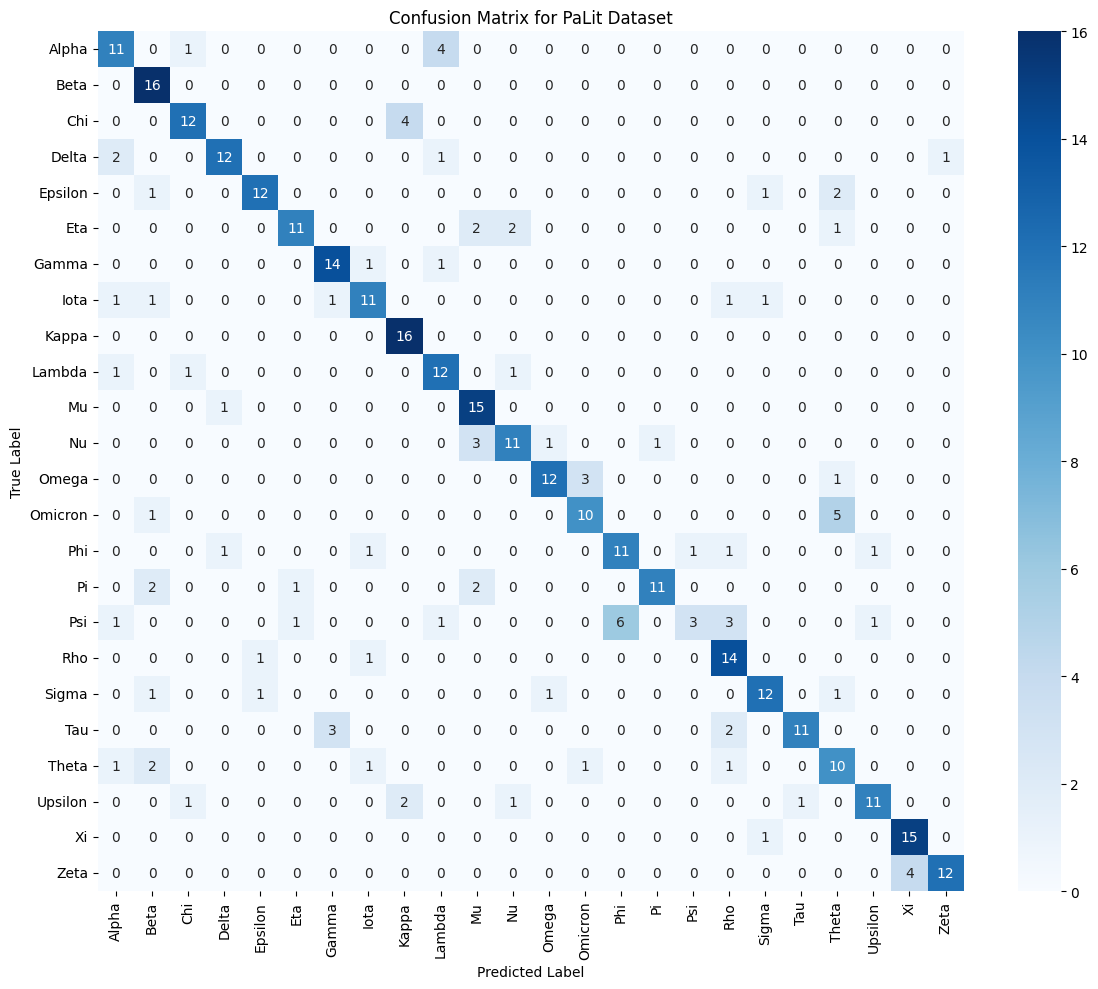

In [15]:
#@title Assess PaLit Predictions

# Merge the classification results with the PaLit metadata
# Assuming the filename format allows joining with the pal_lit_df (e.g., based on Publication or TM)
# We need to extract relevant info from filename to merge with pal_lit_df

# Extract TM from filename for merging
palit_results_df['TM'] = palit_results_df['filename'].apply(lambda x: int(x.split('_')[1]))

# Merge with the pal_lit_df
# Assuming 'TM' is the common column to merge on
# Inner join to keep only records present in both dataframes
palit_assessment_df = pd.merge(palit_results_df, pal_lit_df, on='TM', how='inner')

# Extract the true letter label from the filename for comparison
palit_assessment_df['true_label'] = palit_assessment_df['filename'].apply(lambda x: x.split('_')[0])

print("Merged DataFrame with true and inferred labels:")
display(palit_assessment_df.head())

# Generate Classification Report
# Need to ensure the labels are in the same order and cover all possible classes
# Use the label_encoder classes to ensure consistency
target_names = label_encoder.classes_

print("\nClassification Report on PaLit Dataset:")
print(classification_report(palit_assessment_df['true_label'], palit_assessment_df['inferred_label'], labels=target_names, zero_division=0))

# Generate Confusion Matrix
cm_palit = confusion_matrix(palit_assessment_df['true_label'], palit_assessment_df['inferred_label'], labels=target_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_palit, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for PaLit Dataset')
plt.tight_layout()
plt.savefig('palit_confusion_matrix.pdf', dpi=300, format='PDF')
plt.show()

In [26]:
palit_results_df['TM'] = palit_results_df.filename.apply(lambda x: int(x.split('_')[1]))
palit_results_df = palit_results_df.merge(pal_lit_df, on='TM')
palit_results_df.sample()

,filename,inferred_label,TM,Publication,Year post quem,Year ante quem,Century,Number of letters
156,Mu_220465_169.png,Mu,220465,P.Bodmer 20,325,399,4,48


Number of mistakes per letter per century for PaLit Dataset:


true_label,Alpha,Chi,Delta,Epsilon,Eta,Gamma,Iota,Lamba,Lambda,Mu,...,Phi,Pi,Psi,Rho,Sigma,Tau,Theta,Upsilon,Xi,Zeta
Century,,,,,,,,,,,,,,,,,,,,,
2,1,0,0,1,0,1,2,0,1,0,...,0,1,4,1,2,0,2,0,0,0
3,2,1,0,0,0,0,0,1,1,1,...,0,2,4,1,1,2,1,0,1,1
4,0,2,1,1,3,0,1,0,0,0,...,2,1,3,0,0,1,0,3,0,1
5,2,1,3,2,2,1,2,0,1,0,...,3,1,2,0,1,2,3,2,0,2


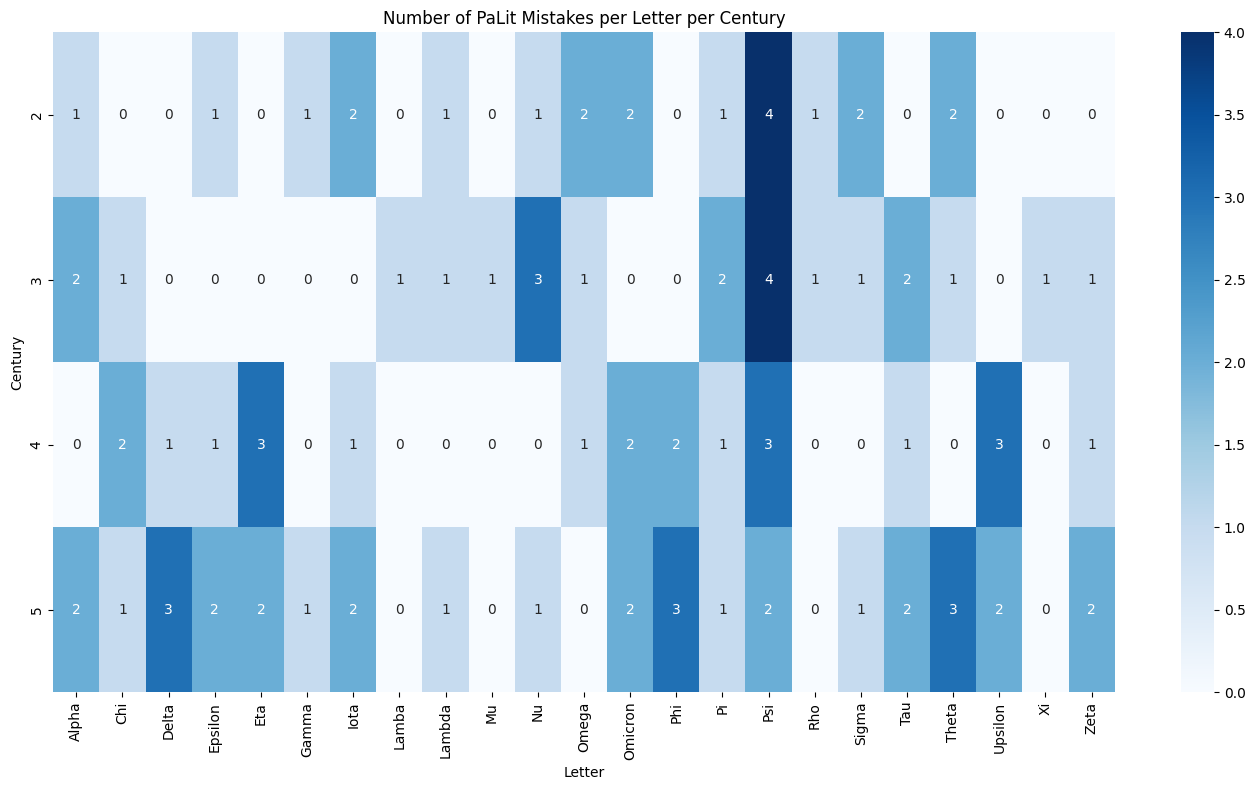

In [28]:
#@title Visualize Number of PaLit Mistakes per Letter per Century

# Filter the DataFrame to include only entries where 'true_label' is not equal to 'inferred_label'
palit_mistakes = palit_assessment_df[palit_assessment_df['true_label'] != palit_assessment_df['inferred_label']].copy()

# Group mistakes by Century and true_label (letter) and count them
mistakes_by_century_letter = palit_mistakes.groupby(['Century', 'true_label']).size().unstack(fill_value=0)

print("Number of mistakes per letter per century for PaLit Dataset:")
display(mistakes_by_century_letter)

# Visualize the number of mistakes per letter per century using a heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(mistakes_by_century_letter, annot=True, fmt='d', cmap='Blues')
plt.title('Number of PaLit Mistakes per Letter per Century')
plt.xlabel('Letter')
plt.ylabel('Century')
plt.tight_layout()
plt.show()

Overall number of mistakes per century for PaLit Dataset:


,Century,num_mistakes
0,2,21
1,3,23
2,4,22
3,5,33


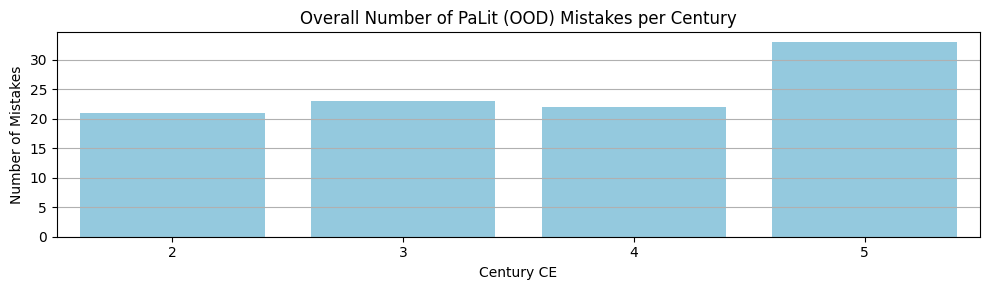

In [31]:
#@title Visualize Overall PaLit Mistakes per Century

# Filter the DataFrame to include only entries where 'true_label' is not equal to 'inferred_label'
palit_mistakes = palit_assessment_df[palit_assessment_df['true_label'] != palit_assessment_df['inferred_label']].copy()

# Group mistakes by Century and count them
palit_mistakes_by_century = palit_mistakes.groupby('Century').size().reset_index(name='num_mistakes')

print("Overall number of mistakes per century for PaLit Dataset:")
display(palit_mistakes_by_century)

# Visualize the overall number of mistakes per century using a bar chart
plt.figure(figsize=(10, 3))
sns.barplot(x='Century', y='num_mistakes', data=palit_mistakes_by_century, color='skyblue')
plt.title('Overall Number of PaLit (OOD) Mistakes per Century')
plt.xlabel('Century CE')
plt.ylabel('Number of Mistakes')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Letter Evolution

In [33]:
#@title Extract Embeddings Function
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    # Removed labels as PaLit loader doesn't provide them initially
    # labels = []

    with torch.no_grad():
        for batch in dataloader:
            # The PaLit loader (SimpleDataset) only yields images, not images and labels
            # if isinstance(batch, (list, tuple)):
            #     images, targets = batch
            #     # labels.extend(targets.numpy())
            # else:
            images = batch
            # targets = None # No targets in this case

            images = images.to(device)
            emb = model.get_embeddings(images)  # (batch_size, 512)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    # No labels to return for the PaLit dataset loader
    # if labels:
    #     labels = np.array(labels)
    #     return embeddings, labels
    # else:
    return embeddings

In [34]:
#@title Extract PaLit Embeddings
palit_embeddings = extract_embeddings(model, palit_loader, device)
print(f"Extracted embeddings for {len(palit_embeddings)} images from PaLit_cliplets.")

Extracted embeddings for 384 images from PaLit_cliplets.


Number of unique Letter+TM combinations: 351
Performing t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Finding and plotting representative images (medoids) and labels on t-SNE plot...


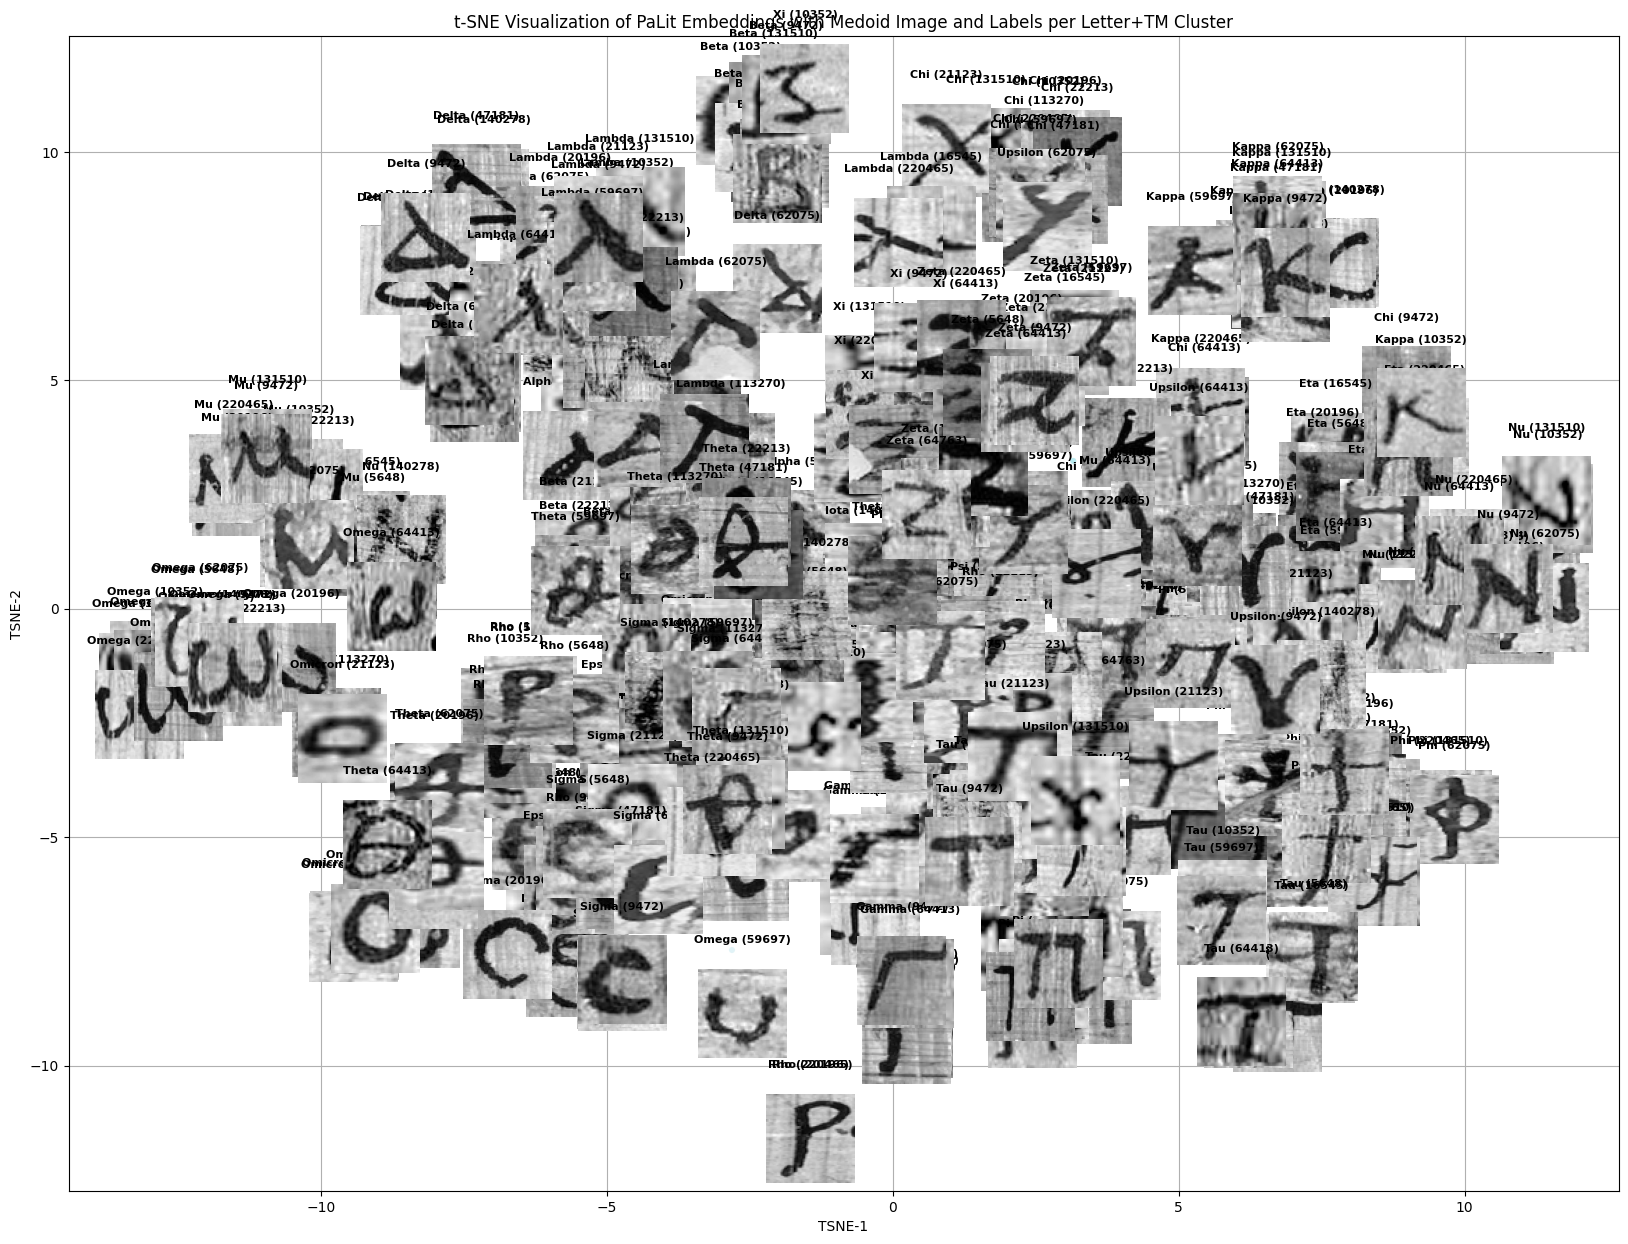

In [43]:
#@title Cluster Embeddings per Letter+TM, Visualize with t-SNE, and Add Representative Image (Medoid) per Cluster with Labels (Fixed Size)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os
from scipy.spatial.distance import cdist
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Ensure the number of embeddings matches the number of entries in the assessment DataFrame
if len(palit_embeddings) != len(palit_assessment_df):
    print("Mismatch between number of embeddings and assessment DataFrame entries. Cannot perform visualization.")
else:
    # Combine embeddings with metadata for easier processing
    palit_embeddings_df = pd.DataFrame(palit_embeddings)
    palit_embeddings_df['true_label'] = palit_assessment_df['true_label'].values
    palit_embeddings_df['TM'] = palit_assessment_df['TM'].values
    palit_embeddings_df['filename'] = palit_assessment_df['filename'].values

    # Create a combined column for clustering
    palit_embeddings_df['letter_tm'] = palit_embeddings_df['true_label'] + '_' + palit_embeddings_df['TM'].astype(str)

    # Determine the number of clusters based on unique letter-TM combinations
    unique_letter_tm = palit_embeddings_df['letter_tm'].unique()
    num_clusters_letter_tm = len(unique_letter_tm)

    print(f"Number of unique Letter+TM combinations: {num_clusters_letter_tm}")

    # Perform t-SNE for visualization (if not already done)
    if 'TSNE-1' not in palit_embeddings_df.columns:
        print("Performing t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
        palit_tsne_embeddings = tsne.fit_transform(palit_embeddings)
        palit_embeddings_df['TSNE-1'] = palit_tsne_embeddings[:, 0]
        palit_embeddings_df['TSNE-2'] = palit_tsne_embeddings[:, 1]

    # --- Visualize t-SNE points and find Medoids ---

    plt.figure(figsize=(20, 15))
    ax = plt.gca() # Get current axes for adding images and text

    # Plot t-SNE points first (optional, can be removed if only images are desired)
    sns.scatterplot(
        x='TSNE-1', y='TSNE-2',
        hue='letter_tm', # Color by combined letter and TM
        palette=sns.color_palette('tab20', len(unique_letter_tm)), # Use a suitable color palette
        data=palit_embeddings_df,
        legend=False, # Don't show legend here
        alpha=0.3, # Make points semi-transparent to see images better
        s=20 # Adjust point size
    )

    # Find and plot medoid image and text label for each cluster
    # image_size_on_plot = 0.6 # Adjust image size on the plot - now using target_size
    target_image_size = (64, 64) # Define fixed size for images
    text_offset_y = 1.5 # Adjust vertical offset for text from image

    print("\nFinding and plotting representative images (medoids) and labels on t-SNE plot...")

    for cluster_name, cluster_df in palit_embeddings_df.groupby('letter_tm'):
        if len(cluster_df) == 0:
            continue

        # Find the medoid in the t-SNE space
        tsne_points = cluster_df[['TSNE-1', 'TSNE-2']].values
        # Calculate pairwise distances
        distances = cdist(tsne_points, tsne_points)
        # Sum distances for each point
        sum_distances = distances.sum(axis=1)
        # Index of the medoid (point with minimum sum of distances)
        medoid_index_in_cluster_df = np.argmin(sum_distances)
        medoid_row = cluster_df.iloc[medoid_index_in_cluster_df]

        medoid_tsne_x = medoid_row['TSNE-1']
        medoid_tsne_y = medoid_row['TSNE-2']
        medoid_filename = medoid_row['filename']
        image_path = os.path.join(palit_image_folder, medoid_filename)

        try:
            img = Image.open(image_path).convert('L') # Grayscale
            # Resize image to a fixed size for plotting
            img_resized = img.resize(target_image_size, Image.Resampling.LANCZOS) # Use LANCZOS for better quality

            # Add image to the plot at the medoid's t-SNE coordinates
            imagebox = OffsetImage(img_resized, zoom=1.0, cmap='gray') # Zoom is 1.0 because we already resized
            ab = AnnotationBbox(imagebox, (medoid_tsne_x, medoid_tsne_y), frameon=False, pad=0.1)
            ax.add_artist(ab)

            # Add text label (TM and letter) above the image
            label_text = f"{medoid_row['true_label']} (TM{medoid_row['TM']})"
            ax.text(medoid_tsne_x, medoid_tsne_y + text_offset_y, label_text,
                    horizontalalignment='center', verticalalignment='bottom',
                    fontsize=8, color='black', weight='bold')

        except Exception as e:
            print(f"Error loading, plotting image, or adding label for {image_path}: {e}")
            continue

    plt.title('t-SNE Visualization of PaLit Embeddings with Medoid Image and Labels per Letter+TM Cluster')
    plt.xlabel('TSNE-1')
    plt.ylabel('TSNE-2')
    plt.grid(True)
    plt.show()

Number of unique Letter+Century combinations: 97
Adding existing t-SNE results to DataFrame...

Finding and plotting representative images (medoids) and labels on t-SNE plot...


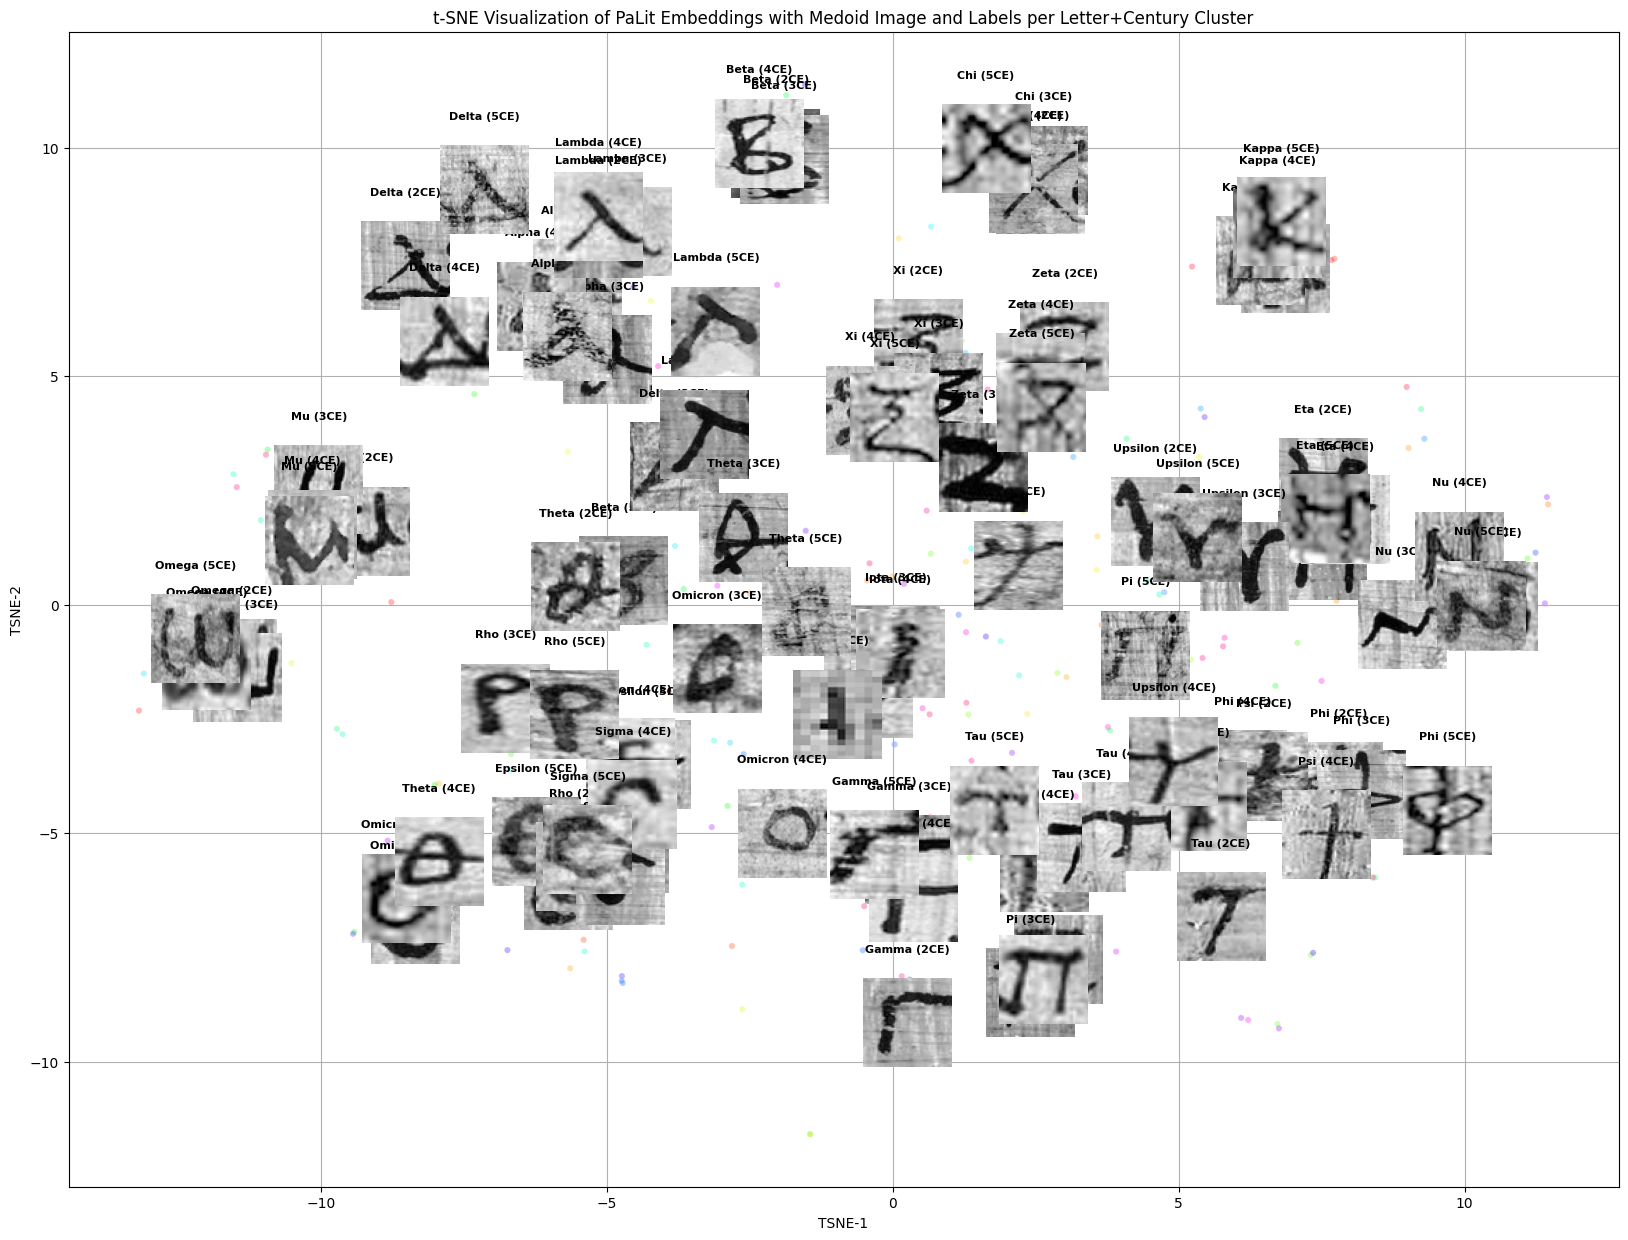

In [44]:
#@title Cluster Embeddings per Letter+Century, Visualize with t-SNE, and Add Representative Image (Medoid) per Cluster with Labels (Fixed Size)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os
from scipy.spatial.distance import cdist
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Ensure the number of embeddings matches the number of entries in the assessment DataFrame
if len(palit_embeddings) != len(palit_assessment_df):
    print("Mismatch between number of embeddings and assessment DataFrame entries. Cannot perform visualization.")
else:
    # Combine embeddings with metadata for easier processing
    palit_embeddings_df = pd.DataFrame(palit_embeddings)
    palit_embeddings_df['true_label'] = palit_assessment_df['true_label'].values
    # Need to get the century from the palit_assessment_df
    palit_embeddings_df['Century'] = palit_assessment_df['Century'].values
    palit_embeddings_df['filename'] = palit_assessment_df['filename'].values

    # Create a combined column for clustering
    palit_embeddings_df['letter_century'] = palit_embeddings_df['true_label'] + '_' + palit_embeddings_df['Century'].astype(str)

    # Determine the number of clusters based on unique letter-century combinations
    unique_letter_century = palit_embeddings_df['letter_century'].unique()
    num_clusters_letter_century = len(unique_letter_century)

    print(f"Number of unique Letter+Century combinations: {num_clusters_letter_century}")

    # Perform t-SNE for visualization (if not already done on these embeddings)
    # Assuming palit_tsne_embeddings was computed on palit_embeddings previously
    # If not, uncomment the following block:
    # print("Performing t-SNE...")
    # tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
    # palit_tsne_embeddings = tsne.fit_transform(palit_embeddings)

    # Add t-SNE results to the DataFrame if not already present
    if 'TSNE-1' not in palit_embeddings_df.columns:
         print("Adding existing t-SNE results to DataFrame...")
         # Assuming palit_tsne_embeddings is available from the previous t-SNE run
         palit_embeddings_df['TSNE-1'] = palit_tsne_embeddings[:, 0]
         palit_embeddings_df['TSNE-2'] = palit_tsne_embeddings[:, 1]


    # --- Visualize t-SNE points and find Medoids ---

    plt.figure(figsize=(20, 15))
    ax = plt.gca() # Get current axes for adding images and text

    # Plot t-SNE points first (optional)
    sns.scatterplot(
        x='TSNE-1', y='TSNE-2',
        hue='letter_century', # Color by combined letter and Century
        palette=sns.color_palette('hsv', len(unique_letter_century)), # Use a suitable color palette
        data=palit_embeddings_df,
        legend=False, # Don't show legend here
        alpha=0.3, # Make points semi-transparent
        s=20 # Adjust point size
    )

    # Find and plot medoid image and text label for each cluster
    # image_size_on_plot = 0.6 # Adjust image size on the plot - now using target_size
    target_image_size = (64, 64) # Define fixed size for images
    text_offset_y = 1.5 # Adjust vertical offset for text from image

    print("\nFinding and plotting representative images (medoids) and labels on t-SNE plot...")

    for cluster_name, cluster_df in palit_embeddings_df.groupby('letter_century'):
        if len(cluster_df) == 0:
            continue

        # Find the medoid in the t-SNE space
        tsne_points = cluster_df[['TSNE-1', 'TSNE-2']].values
        # Calculate pairwise distances
        distances = cdist(tsne_points, tsne_points)
        # Sum distances for each point
        sum_distances = distances.sum(axis=1)
        # Index of the medoid (point with minimum sum of distances)
        medoid_index_in_cluster_df = np.argmin(sum_distances)
        medoid_row = cluster_df.iloc[medoid_index_in_cluster_df]

        medoid_tsne_x = medoid_row['TSNE-1']
        medoid_tsne_y = medoid_row['TSNE-2']
        medoid_filename = medoid_row['filename']
        image_path = os.path.join(palit_image_folder, medoid_filename)

        try:
            img = Image.open(image_path).convert('L') # Grayscale
            # Resize image to a fixed size for plotting
            img_resized = img.resize(target_image_size, Image.Resampling.LANCZOS) # Use LANCZOS for better quality

            # Add image to the plot at the medoid's t-SNE coordinates
            imagebox = OffsetImage(img_resized, zoom=1.0, cmap='gray') # Zoom is 1.0 because we already resized
            ab = AnnotationBbox(imagebox, (medoid_tsne_x, medoid_tsne_y), frameon=False, pad=0.1)
            ax.add_artist(ab)

            # Add text label (Letter and Century) above the image
            label_text = f"{medoid_row['true_label']} ({medoid_row['Century']}CE)"
            ax.text(medoid_tsne_x, medoid_tsne_y + text_offset_y, label_text,
                    horizontalalignment='center', verticalalignment='bottom',
                    fontsize=8, color='black', weight='bold')

        except Exception as e:
            print(f"Error loading, plotting image, or adding label for {image_path}: {e}")
            continue

    plt.title('t-SNE Visualization of PaLit Embeddings with Medoid Image and Labels per Letter+Century Cluster')
    plt.xlabel('TSNE-1')
    plt.ylabel('TSNE-2')
    plt.grid(True)
    plt.show()